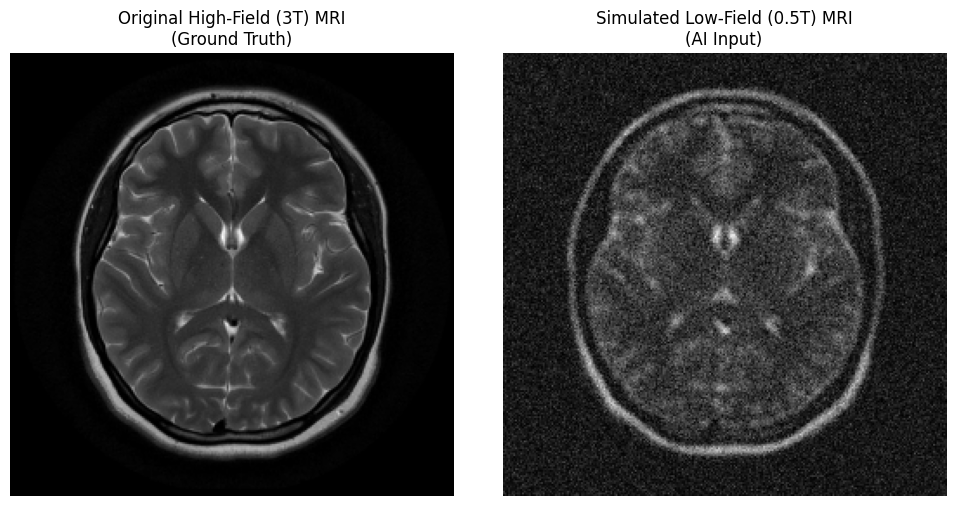

In [2]:
# CELL 1: Install requirements and import libraries
!pip install -q monai torch torchvision matplotlib

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

def simulate_low_field_mri(image, crop_percent=0.3, noise_std=15):
    """
    Simulates a low-field MRI by truncating high frequencies in k-space 
    and adding Rician noise.
    """
    # 1. Convert to K-Space using Fast Fourier Transform (FFT)
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)

    # 2. Truncate K-space (Simulates low resolution 0.5T field)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    
    # Keep only the center frequencies
    r = int((rows * crop_percent) / 2)
    c = int((cols * crop_percent) / 2)
    mask[crow-r:crow+r, ccol-c:ccol+c] = 1
    
    f_shift_filtered = f_shift * mask

    # 3. Convert back to Image Space
    f_ishift = np.fft.ifftshift(f_shift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    # 4. Add Rician Noise (MRI specific noise)
    noise1 = np.random.normal(0, noise_std, img_back.shape)
    noise2 = np.random.normal(0, noise_std, img_back.shape)
    noisy_img = np.sqrt((img_back + noise1)**2 + noise2**2)
    
    # Normalize back to 0-255 for visualization
    noisy_img = cv2.normalize(noisy_img, None, 0, 255, cv2.NORM_MINMAX)
    return noisy_img.astype(np.uint8)

# --- LET'S TEST IT ON KAGGLE DATA ---
# Replace this path with the actual path of the dataset you added!
# Kaggle datasets are usually stored in '/kaggle/input/dataset-name/'
# Here is a generic way to find the first JPG in your input folder:

image_paths = glob.glob('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/1 no.jpeg', recursive=True)

if len(image_paths) > 0:
    test_img_path = image_paths[0]
    
    # Read as grayscale
    original_mri = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize for consistency (e.g., 256x256)
    original_mri = cv2.resize(original_mri, (256, 256))

    # Run our Physics Simulation
    simulated_0_5T = simulate_low_field_mri(original_mri, crop_percent=0.3, noise_std=20)

    # Plotting
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original_mri, cmap='gray')
    plt.title('Original High-Field (3T) MRI\n(Ground Truth)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(simulated_0_5T, cmap='gray')
    plt.title('Simulated Low-Field (0.5T) MRI\n(AI Input)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Could not find any images. Make sure you clicked 'Add Data' on the right panel!")

In [1]:
# Run this to collect all images for the training pipeline!
import glob

image_paths =[]
for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG'):
    image_paths.extend(glob.glob(f'/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/**/{ext}', recursive=True))

print(f"Successfully found {len(image_paths)} images for training!")

Successfully found 506 images for training!


In [2]:
# CELL 4: Visualizing the AI's Super-Resolution & Metrics!
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Set model to evaluation mode
model.eval()

# Get one batch from validation set
inputs, targets = next(iter(val_loader))
inputs, targets = inputs.to(device), targets.to(device)

# Pass the degraded input through the AI
with torch.no_grad():
    outputs = model(inputs)

# Convert tensors back to numpy arrays for plotting (Take the first image in the batch)
input_img = inputs[0, 0].cpu().numpy()
target_img = targets[0, 0].cpu().numpy()
output_img = outputs[0, 0].cpu().numpy()

# Ensure values are strictly between 0 and 1 for metrics calculation
output_img = np.clip(output_img, 0, 1)

# Calculate Clinical Metrics
calc_psnr = psnr(target_img, output_img, data_range=1.0)
calc_ssim = ssim(target_img, output_img, data_range=1.0)

# Plotting the 1x3 Grid
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_img, cmap='gray')
plt.title('1. Simulated 0.5T (Input)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(output_img, cmap='gray')
plt.title(f'2. AI Reconstructed Output\nPSNR: {calc_psnr:.2f} | SSIM: {calc_ssim:.2f}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(target_img, cmap='gray')
plt.title('3. Actual 3T (Ground Truth)')
plt.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

Complete Code pipeline


In [3]:
# CELL 1
!pip install -q monai torch torchvision scikit-image

import os
import cv2
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from monai.networks.nets import UNet
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def simulate_low_field_mri(image, crop_percent=0.3, noise_std=20):
    """
    Simulates a low-field MRI by truncating high frequencies in k-space 
    and adding Rician noise.
    """
    # 1. Convert to K-Space using Fast Fourier Transform (FFT)
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)

    # 2. Truncate K-space (Simulates low resolution)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    
    r = int((rows * crop_percent) / 2)
    c = int((cols * crop_percent) / 2)
    mask[crow-r:crow+r, ccol-c:ccol+c] = 1
    f_shift_filtered = f_shift * mask

    # 3. Convert back to Image Space
    f_ishift = np.fft.ifftshift(f_shift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    # 4. Add Rician Noise
    noise1 = np.random.normal(0, noise_std, img_back.shape)
    noise2 = np.random.normal(0, noise_std, img_back.shape)
    noisy_img = np.sqrt((img_back + noise1)**2 + noise2**2)
    
    noisy_img = cv2.normalize(noisy_img, None, 0, 255, cv2.NORM_MINMAX)
    return noisy_img.astype(np.uint8)

# Find all images in the Navoneel Kaggle dataset
image_paths =[]
for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG'):
    image_paths.extend(glob.glob(f'/kaggle/input/**/{ext}', recursive=True))

print(f"Successfully found {len(image_paths)} images for training!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.7 MB/s eta 0:00:0000:0100:01


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-10 16:39:17.141437: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778431157.364123      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778431157.428275      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778431157.967988      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778431157.968021      57 computation_placer.cc:1

Successfully found 506 images for training!


In [4]:
# CELL 2
class MRIDataset(Dataset):
    def __init__(self, image_paths, transform_fn, img_size=256):
        self.image_paths = image_paths
        self.transform_fn = transform_fn
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        # Load high-res 3T image
        original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if original is None:
            # Fallback if an image is corrupted
            original = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
            
        original = cv2.resize(original, (self.img_size, self.img_size))

        # Generate simulated 0.5T low-field image
        simulated = self.transform_fn(original, crop_percent=0.3, noise_std=20)

        # Normalize to 0-1 for Neural Network
        original = original.astype(np.float32) / 255.0
        simulated = simulated.astype(np.float32) / 255.0

        # Add channel dimension (C, H, W) -> (1, 256, 256)
        original = np.expand_dims(original, axis=0)
        simulated = np.expand_dims(simulated, axis=0)

        return torch.tensor(simulated), torch.tensor(original)

# Split data
train_paths, val_paths = train_test_split(image_paths, test_size=0.1, random_state=42)

train_dataset = MRIDataset(train_paths, simulate_low_field_mri)
val_dataset = MRIDataset(val_paths, simulate_low_field_mri)

# Create DataLoaders (Batch size 8)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Training batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Training batches: 57 | Validation batches: 7


In [5]:
# CELL 3
# Setup GPU Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Define the MONAI U-Net
model = UNet(
    spatial_dims=2,            
    in_channels=1,             
    out_channels=1,            
    channels=(16, 32, 64, 128, 256), 
    strides=(2, 2, 2, 2),      
    num_res_units=2            
).to(device)

# Loss and Optimizer
criterion = nn.L1Loss() # Mean Absolute Error
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training Loop
epochs = 25

print("--- Starting Training ---")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    # Validation Loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

print("--- Training Complete! ---")

Training on device: cuda
--- Starting Training ---
Epoch [1/25] | Train Loss: 0.1968 | Val Loss: 0.1040
Epoch [2/25] | Train Loss: 0.0918 | Val Loss: 0.0840
Epoch [3/25] | Train Loss: 0.0753 | Val Loss: 0.0692
Epoch [4/25] | Train Loss: 0.0636 | Val Loss: 0.0619
Epoch [5/25] | Train Loss: 0.0595 | Val Loss: 0.0638
Epoch [6/25] | Train Loss: 0.0571 | Val Loss: 0.0536
Epoch [7/25] | Train Loss: 0.0494 | Val Loss: 0.0477
Epoch [8/25] | Train Loss: 0.0457 | Val Loss: 0.0459
Epoch [9/25] | Train Loss: 0.0438 | Val Loss: 0.0478
Epoch [10/25] | Train Loss: 0.0415 | Val Loss: 0.0410
Epoch [11/25] | Train Loss: 0.0400 | Val Loss: 0.0425
Epoch [12/25] | Train Loss: 0.0399 | Val Loss: 0.0393
Epoch [13/25] | Train Loss: 0.0396 | Val Loss: 0.0409
Epoch [14/25] | Train Loss: 0.0368 | Val Loss: 0.0377
Epoch [15/25] | Train Loss: 0.0365 | Val Loss: 0.0382
Epoch [16/25] | Train Loss: 0.0360 | Val Loss: 0.0424
Epoch [17/25] | Train Loss: 0.0365 | Val Loss: 0.0352
Epoch [18/25] | Train Loss: 0.0358 | Val

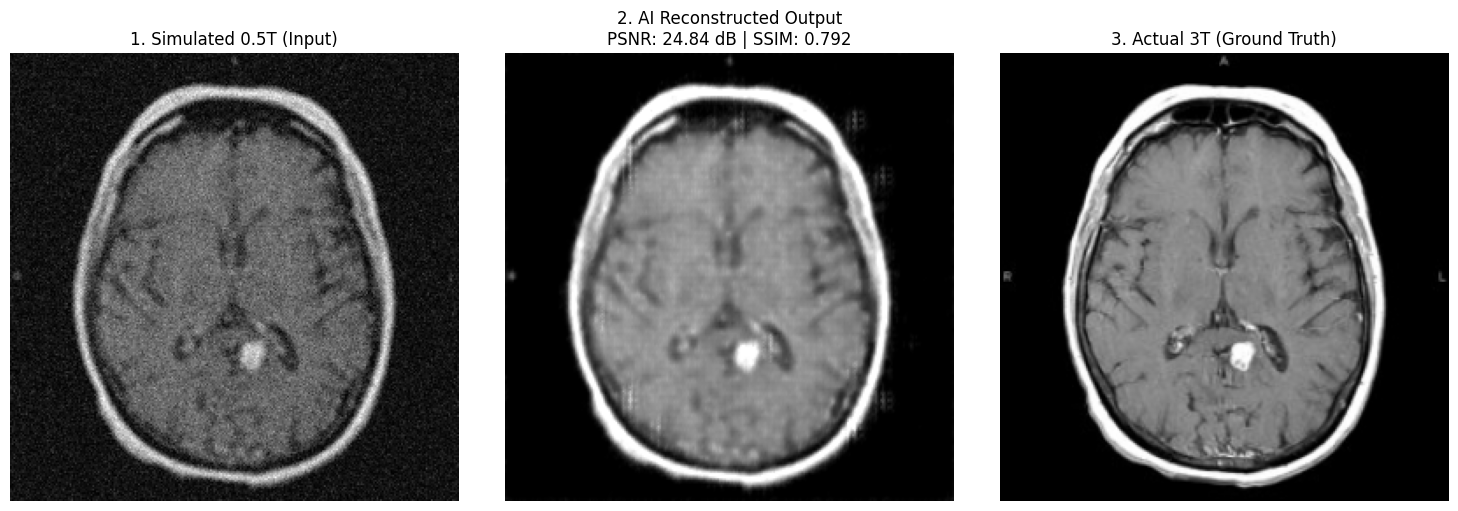

Final SSIM Achieved: 0.792
Final PSNR Achieved: 24.84 dB


In [6]:
# CELL 4
# Set model to evaluation mode
model.eval()

# Get one batch from validation set
inputs, targets = next(iter(val_loader))
inputs, targets = inputs.to(device), targets.to(device)

# AI Inference
with torch.no_grad():
    outputs = model(inputs)

# Convert back to CPU numpy arrays
input_img = inputs[0, 0].cpu().numpy()
target_img = targets[0, 0].cpu().numpy()
output_img = outputs[0, 0].cpu().numpy()

# Clip output between 0 and 1
output_img = np.clip(output_img, 0, 1)

# Calculate Clinical Metrics (For Resume & GitHub)
calc_psnr = psnr(target_img, output_img, data_range=1.0)
calc_ssim = ssim(target_img, output_img, data_range=1.0)

# Plotting the 1x3 Grid
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_img, cmap='gray')
plt.title('1. Simulated 0.5T (Input)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(output_img, cmap='gray')
plt.title(f'2. AI Reconstructed Output\nPSNR: {calc_psnr:.2f} dB | SSIM: {calc_ssim:.3f}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(target_img, cmap='gray')
plt.title('3. Actual 3T (Ground Truth)')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Final SSIM Achieved: {calc_ssim:.3f}")
print(f"Final PSNR Achieved: {calc_psnr:.2f} dB")